# 🏥 의료 데이터 분석
## 04. 머신러닝 모델링 및 임상 인사이트 도출

---

### 🎯 분석 설계

#### 왜 LOS(입원 기간)를 목적변수로 선택했는가?

LOS는 의료 현장에서 **병상 회전율, 자원 배분, 퇴원 계획**에 직결되는 지표로,  
임상 의사결정 지원 시스템에서 가장 널리 예측하는 타깃 중 하나다.  
MIMIC-III 기반 연구를 포함해 수십 편의 EMR 분석 논문이 LOS를 예측 대상으로 채택한다.

> 단, 본 데이터에서는 **`LabTestCount`(총 검사 횟수)** 가 입원 기간과 함께 누적되는  
> 결과론적 변수(outcome-driven variable)이므로, 이를 제거하고 분석한다.  
> EDA에서 확인된 `LabTestCount` ↔ `LengthOfStay` 상관계수 **0.993** 이  
> "오래 입원했기 때문에 검사가 많다"는 역인과 관계를 강하게 시사하기 때문이다.

#### 이 노트북의 두 가지 역할

| 파트 | 목적 | 핵심 질문 |
|------|------|----------|
| **Part 1. 예측 모델링** | 구조적 임상 지표로 LOS를 예측할 수 있는가 | 모델 성능 + 일반화 검증 |
| **Part 2. 탐색적 해석** | 모델을 해석 도구로 전환해 임상 신호를 발굴 | 어떤 지표가 LOS를 결정하는가 |

> 예측 정확도를 높이는 것보다, **"무엇이 입원을 길게 만드는가"** 를 실증하는 것이 궁극적 목표다.


---
## 1. 환경 설정 및 데이터 로드

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from xgboost import XGBRegressor
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
shap.initjs()

In [2]:
df_main = pd.read_csv('../outputs/processed_healthcare_data.csv', encoding='utf-8-sig')

print(f"✅ 데이터 로드: {df_main.shape[0]}행 × {df_main.shape[1]}열")
print(f"   타깃 변수 LengthOfStay — 평균: {df_main['LengthOfStay'].mean():.1f}일, "
      f"중앙값: {df_main['LengthOfStay'].median():.1f}일, "
      f"범위: {df_main['LengthOfStay'].min()}~{df_main['LengthOfStay'].max()}일")
df_main.head(3)

✅ 데이터 로드: 372행 × 165열
   타깃 변수 LengthOfStay — 평균: 10.6일, 중앙값: 10.0일, 범위: 2~19일


,PatientID,AdmissionID,AdmissionStartDate,AdmissionEndDate,LengthOfStay,AdmissionYear,AdmissionMonth,AdmissionDayOfWeek,AdmissionDayName,LengthOfStayCategory,...,Lab_Trend_METABOLIC: SODIUM,Lab_Trend_METABOLIC: TOTAL PROTEIN,Lab_Trend_URINALYSIS: PH,Lab_Trend_URINALYSIS: RED BLOOD CELLS,Lab_Trend_URINALYSIS: SPECIFIC GRAVITY,Lab_Trend_URINALYSIS: WHITE BLOOD CELLS,LabTestCount,LabTestVariety,Total_Abnormal_Count,Total_Lab_Variability
0,7A025E77-7832-4F53-B9A7-09A3F98AC17E,7,2011-10-12 14:55:02.027,2011-10-22 01:16:07.557,9,2011,10,2,수,중기(8-14일),...,15.7,0.4,0.1,-0.3,0.0,3.7,230,35,34.0,6.985972
1,DCE5AEB8-6DB9-4106-8AE4-02CCC5C23741,1,1993-02-11 18:57:04.003,1993-02-24 17:22:29.713,12,1993,2,3,목,중기(8-14일),...,-14.1,1.3,-0.5,-1.4,0.0,1.1,355,35,49.0,8.480702
2,DCE5AEB8-6DB9-4106-8AE4-02CCC5C23741,2,2002-11-28 19:06:31.117,2002-12-04 19:14:40.797,6,2002,11,3,목,단기(4-7일),...,17.6,-1.8,-1.5,-0.2,0.0,0.3,202,35,28.0,6.837585


---
## 2. 피처 설계 — 임상 신호 중심 구성

### 03_EDA에서 제기된 문제

EDA에서 `LabTestCount` ↔ `LengthOfStay` 상관계수 **0.993** 을 확인했다.  
이 변수를 포함하면 모델은 높은 R²를 달성하지만, **임상 신호의 기여도가 완전히 가려진다.**

### 피처 구성 원칙

```
❌ 제외  LabTestCount       — 입원 기간의 결과 (역인과 위험)

✅ 사용  [이상 소견 누적]   Total_Abnormal_Count, Abnormal_Sum 계열  (36개)
         [변동성]           Total_Lab_Variability, Lab_Std 계열       (36개)
         [시간 추이]        Lab_Trend 계열                             (35개)
         [검사 기초값]      Lab_Mean 계열                              (35개)
         [검사 다양성]      LabTestVariety                              (1개)
                                                           총 143개 피처
```


In [3]:
EXCLUDE = ['LabTestCount']

all_candidates = [c for c in df_main.columns
                  if any(x in c for x in ['Mean', 'Std', 'Trend', 'Count',
                                           'Variability', 'Variety', 'Sum', 'Abnormal'])]
features = [c for c in all_candidates if c not in EXCLUDE]

X = df_main[features].fillna(0)
y = df_main['LengthOfStay']

# 피처 그룹 분류
group_map = {
    '이상 누적': [c for c in features if 'Abnormal' in c or ('Sum' in c and 'Abnormal' in c)],
    '변동성':   [c for c in features if 'Variability' in c or ('Std' in c and 'Total' not in c)],
    '시간 추이': [c for c in features if 'Trend' in c],
    '검사 평균': [c for c in features if 'Mean' in c],
    '검사 다양성': [c for c in features if 'Variety' in c],
}

print(f"최종 피처 수: {len(features)}개  (LabTestCount 제외)")
for g, cols in group_map.items():
    if cols:
        print(f"  [{g}] {len(cols)}개")

최종 피처 수: 143개  (LabTestCount 제외)
  [이상 누적] 36개
  [변동성] 36개
  [시간 추이] 35개
  [검사 평균] 35개
  [검사 다양성] 1개


---
# Part 1. 예측 모델링

> **핵심 질문:** 구조적 임상 지표(이상 누적·변동성·추이) 143개만으로 LOS를 예측할 수 있는가?  
> LabTestCount를 제거한 조건에서도 R² 0.9 이상이 가능한지 확인한다.


---
## 3. 데이터 분할

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (297, 143) | Test: (75, 143)


---
## 4. 모델 학습

### 모델 선택 근거

| 모델 | 역할 | 선택 이유 |
|------|------|----------|
| Linear Regression | Baseline | 선형 가정 하의 하한선 — 비선형 모델의 이점 측정 기준 |
| Random Forest + GridSearchCV | Main | 변수 간 비선형 상호작용 포착, 배깅 기반 안정성 |
| XGBoost | Challenger | Gradient Boosting으로 잔차 순차 학습, RF와 전략 상이 |

03_EDA에서 PCA 주성분 설명력이 낮고(PC1 = 7.0%) t-SNE에서 선형 구조가 없음을 확인했다.  
→ 비선형 패턴 포착에 유리한 트리 기반 모델이 적합하다고 판단.


In [5]:
# 4-1. Linear Regression (Baseline)
lr = LinearRegression().fit(X_train, y_train)
yp_lr = lr.predict(X_test)

# 4-2. Random Forest + GridSearchCV
print("⚙️  Random Forest GridSearchCV 탐색 중...")
rf_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    {'n_estimators': [100, 200], 'max_depth': [5, 10, 20], 'min_samples_split': [2, 5, 10]},
    cv=3, scoring='r2', n_jobs=-1
).fit(X_train, y_train)
best_rf = rf_search.best_estimator_
yp_rf = best_rf.predict(X_test)
print(f"   최적 파라미터: {rf_search.best_params_}")

# 4-3. XGBoost
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5,
                   random_state=42, verbosity=0).fit(X_train, y_train)
yp_xgb = xgb.predict(X_test)

print("\n✅ 3개 모델 학습 완료")

⚙️  Random Forest GridSearchCV 탐색 중...
   최적 파라미터: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}

✅ 3개 모델 학습 완료


---
## 5. 모델 평가 — 성능 비교 + 교차 검증

**5-Fold Cross Validation을 함께 수행하는 이유:**  
샘플 수 372건(환자 100명)이라는 소규모 데이터에서는 단일 Train/Test 분할 결과가  
분할 방식에 따라 크게 달라질 수 있다. CV를 통해 일반화 성능의 신뢰 구간을 확인한다.


,모델,R²,MAE,RMSE,CV R² (mean),CV R² (std)
0,Linear Regression,0.8251,1.697,2.172,0.7116,0.0676
1,Random Forest (Tuned),0.9163,1.157,1.502,0.8904,0.0351
2,XGBoost,0.9176,1.123,1.491,0.8723,0.0299


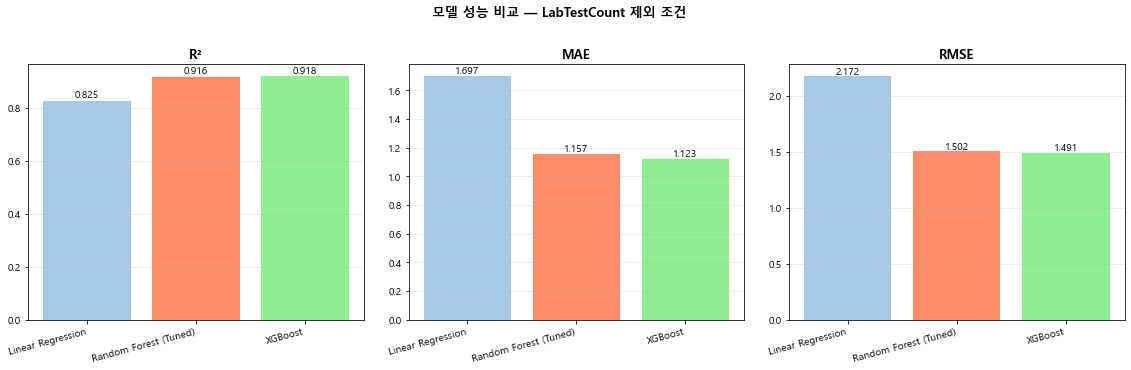


📌 최우수 모델: XGBoost (Test R² = 0.918)

💡 해석 포인트:
  - Linear Regression vs 트리 모델 R² 격차 → 비선형 구조 존재 여부
  - CV std 크면 소규모(100명) 데이터의 분할 민감성 노출


In [6]:
def metrics(y_true, y_pred):
    return {
        'R²':   round(r2_score(y_true, y_pred), 4),
        'MAE':  round(mean_absolute_error(y_true, y_pred), 3),
        'RMSE': round(np.sqrt(mean_squared_error(y_true, y_pred)), 3),
    }

# Test Set 성능
rows = []
for name, model, yp in [('Linear Regression', lr, yp_lr),
                         ('Random Forest (Tuned)', best_rf, yp_rf),
                         ('XGBoost', xgb, yp_xgb)]:
    m = metrics(y_test, yp)
    cv = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')
    rows.append({'모델': name, **m,
                 'CV R² (mean)': round(cv.mean(), 4),
                 'CV R² (std)': round(cv.std(), 4)})

result_df = pd.DataFrame(rows)
display(result_df)

# 시각화
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['#A8C8E8', '#FF8C69', '#90EE90']
for i, col in enumerate(['R²', 'MAE', 'RMSE']):
    bars = axes[i].bar(result_df['모델'], result_df[col], color=colors)
    axes[i].set_title(col, fontsize=13, weight='bold')
    axes[i].set_xticklabels(result_df['모델'], rotation=15, ha='right')
    axes[i].grid(axis='y', alpha=0.3)
    for bar, v in zip(bars, result_df[col]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.005, f'{v:.3f}',
                     ha='center', va='bottom', fontsize=10)
plt.suptitle('모델 성능 비교 — LabTestCount 제외 조건', fontsize=13, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

# CV 결과 해석
best_model_name = result_df.loc[result_df['R²'].idxmax(), '모델']
best_r2 = result_df['R²'].max()
print(f"\n📌 최우수 모델: {best_model_name} (Test R² = {best_r2:.3f})")
print("\n💡 해석 포인트:")
print("  - Linear Regression vs 트리 모델 R² 격차 → 비선형 구조 존재 여부")
print("  - CV std 크면 소규모(100명) 데이터의 분할 민감성 노출")

---
## 6. Actual vs Predicted

세 모델의 예측 분포를 시각화한다.  
이상적인 예측은 모든 점이 붉은 대각선(y=x) 위에 놓이는 형태다.


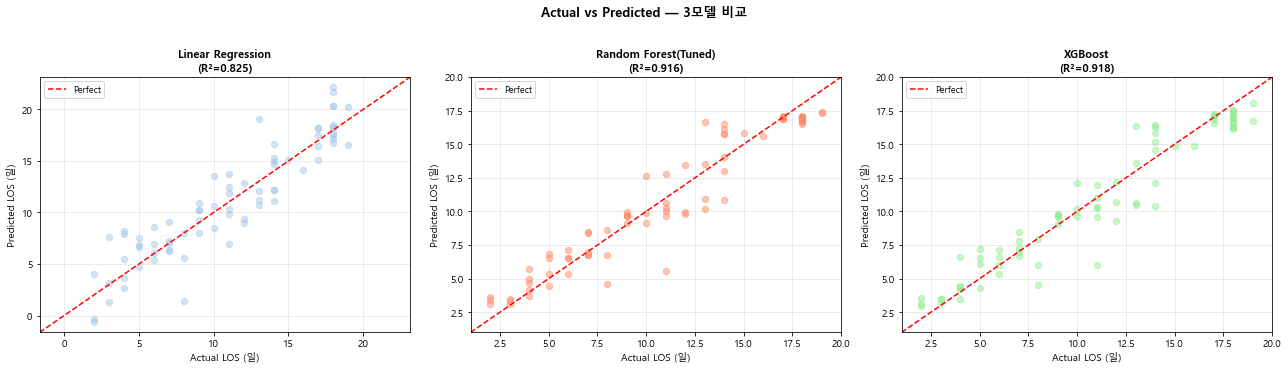

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (name, yp, color) in zip(axes, [
        ('Linear Regression',    yp_lr,  '#A8C8E8'),
        ('Random Forest(Tuned)', yp_rf,  '#FF8C69'),
        ('XGBoost',             yp_xgb, '#90EE90')]):
    ax.scatter(y_test, yp, alpha=0.5, color=color, s=40)
    lim = [min(y_test.min(), yp.min())-1, max(y_test.max(), yp.max())+1]
    ax.plot(lim, lim, 'r--', lw=1.5, label='Perfect')
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel('Actual LOS (일)'); ax.set_ylabel('Predicted LOS (일)')
    ax.set_title(f'{name}\n(R²={r2_score(y_test,yp):.3f})', fontsize=11, weight='bold')
    ax.legend(fontsize=9); ax.grid(alpha=0.3)
plt.suptitle('Actual vs Predicted — 3모델 비교', fontsize=13, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
# Part 2. 탐색적 해석 — 모델을 임상 신호 발굴 도구로 전환

> Part 1에서 구축한 **XGBoost (Test R²=0.918, MAE=1.123일)** 를 해석 도구로 활용한다.  
> "어떤 임상 지표가 LOS를 결정하는가" — EDA에서 세운 가설을 모델로 실증한다.

```
[EDA 가설]                             [모델로 검증]
──────────────────────────────────────────────────────────
단순 평균값은 충분하지 않다     →  Lab_Mean 그룹 SHAP 기여도 최하위 (10.1%)
이상 누적이 핵심 신호다        →  Total_Abnormal_Count SHAP 압도적 1위
변동성이 임상 불안정성을 반영   →  Variability/Std 그룹 SHAP 상위권
```


---
## 7. SHAP 분석 — 변수 기여도 실증

SHAP(SHapley Additive exPlanations)으로 각 피처가 LOS 예측에  
얼마나, 어느 방향으로 기여하는지를 실증한다.  

**해석 방법:**  
- 점이 오른쪽(SHAP > 0): 해당 피처가 이 환자의 LOS를 늘리는 방향으로 기여  
- 점이 왼쪽(SHAP < 0): LOS를 줄이는 방향으로 기여  
- 점 색상: 붉을수록 피처값이 높음, 파랄수록 낮음


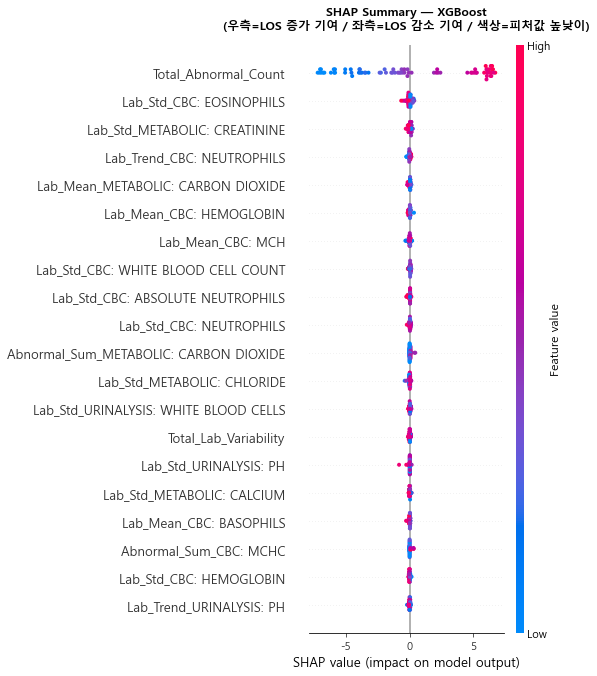


📊 SHAP 기여도 상위 10개 (XGBoost):
   1. Total_Abnormal_Count                   ████████████████████ (4.2031)
   2. Lab_Std_CBC: EOSINOPHILS                (0.1329)
   3. Lab_Std_METABOLIC: CREATININE           (0.0910)
   4. Lab_Trend_CBC: NEUTROPHILS              (0.0589)
   5. Lab_Mean_METABOLIC: CARBON DIOXIDE      (0.0560)
   6. Lab_Mean_CBC: HEMOGLOBIN                (0.0523)
   7. Lab_Mean_CBC: MCH                       (0.0500)
   8. Lab_Std_CBC: WHITE BLOOD CELL COUNT     (0.0493)
   9. Lab_Std_CBC: ABSOLUTE NEUTROPHILS       (0.0423)
  10. Lab_Std_CBC: NEUTROPHILS                (0.0396)


In [8]:
# 최우수 트리 모델로 SHAP 수행
best_tree = best_rf if result_df.loc[result_df['모델']=='Random Forest (Tuned)', 'R²'].values[0] >= \
                       result_df.loc[result_df['모델']=='XGBoost', 'R²'].values[0] else xgb
best_tree_name = 'Random Forest (Tuned)' if best_tree is best_rf else 'XGBoost'

explainer   = shap.TreeExplainer(best_tree)
shap_values = explainer.shap_values(X_test)

# Summary plot
plt.figure(figsize=(11, 7))
shap.summary_plot(shap_values, X_test, show=False)
plt.title(f'SHAP Summary — {best_tree_name}\n'
          '(우측=LOS 증가 기여 / 좌측=LOS 감소 기여 / 색상=피처값 높낮이)',
          fontsize=12, weight='bold', pad=15)
plt.tight_layout()
plt.show()

# 순위 출력
mean_shap = pd.Series(np.abs(shap_values).mean(axis=0),
                      index=X_test.columns).sort_values(ascending=False)
print(f"\n📊 SHAP 기여도 상위 10개 ({best_tree_name}):")
for rank, (feat, val) in enumerate(mean_shap.head(10).items(), 1):
    bar = '█' * int(val / mean_shap.max() * 20)
    print(f"  {rank:2d}. {feat:38s} {bar} ({val:.4f})")

---
## 8. 설계 의도별 기여도 집계 — 가설 검증

개별 변수 143개의 순위가 아닌,  
**"어떤 종류의 임상 신호"가 LOS를 결정하는가**를 그룹 단위로 집계하여 검증한다.  

EDA에서 세운 가설 — "이상 누적·변동성이 단순 평균보다 중요하다" — 의 최종 검증이다.


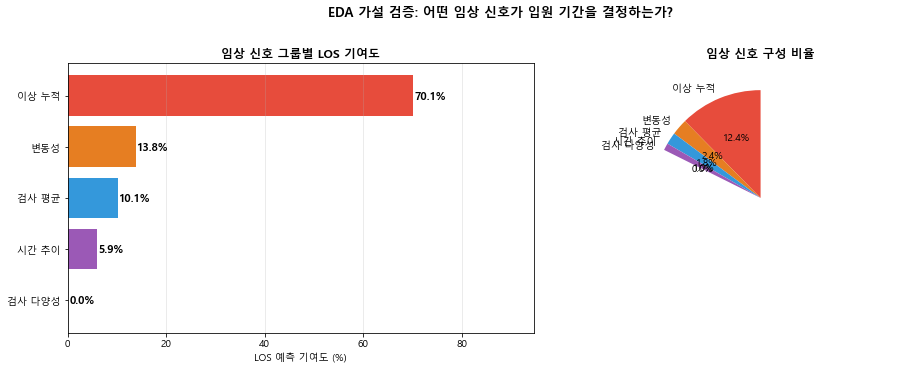


📌 최고 기여 그룹: '이상 누적' (70.1%)
   EDA 가설(이상 누적·변동성·추이) 지지 여부: ✅ 지지됨

   검사 평균(Lab_Mean) 기여도: 10.1%
   → '단순 평균값은 충분하지 않다'는 EDA 초기 가설과의 일관성 확인


In [9]:
# 그룹별 SHAP 합산
group_shap = {}
for gname, gcols in group_map.items():
    valid = [c for c in gcols if c in X_test.columns]
    if valid:
        idx = [list(X_test.columns).index(c) for c in valid]
        group_shap[gname] = float(np.abs(shap_values[:, idx]).mean())

gdf = pd.Series(group_shap).sort_values(ascending=True)
total = gdf.sum()
gdf_pct = gdf / total * 100

group_colors = {
    '이상 누적':  '#E74C3C',
    '변동성':     '#E67E22',
    '시간 추이':  '#9B59B6',
    '검사 평균':  '#3498DB',
    '검사 다양성':'#95A5A6',
}
bar_colors = [group_colors.get(k, '#BDC3C7') for k in gdf.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 가로 막대
bars = axes[0].barh(gdf.index, gdf_pct.values, color=bar_colors)
for bar, val in zip(bars, gdf_pct.values):
    axes[0].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontsize=11, weight='bold')
axes[0].set_xlabel('LOS 예측 기여도 (%)')
axes[0].set_title('임상 신호 그룹별 LOS 기여도', fontsize=12, weight='bold')
axes[0].set_xlim(0, gdf_pct.max() * 1.35)
axes[0].grid(axis='x', alpha=0.3)

# 파이
sorted_g = gdf.sort_values(ascending=False)
pie_colors = [group_colors.get(k, '#BDC3C7') for k in sorted_g.index]
axes[1].pie(sorted_g.values, labels=sorted_g.index,
            autopct='%1.1f%%', colors=pie_colors,
            startangle=90, textprops={'fontsize': 10})
axes[1].set_title('임상 신호 구성 비율', fontsize=12, weight='bold')

plt.suptitle('EDA 가설 검증: 어떤 임상 신호가 입원 기간을 결정하는가?',
             fontsize=13, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

top_group = gdf_pct.idxmax()
hypo_groups = {'이상 누적', '변동성', '시간 추이'}
print(f"\n📌 최고 기여 그룹: '{top_group}' ({gdf_pct.max():.1f}%)")
print(f"   EDA 가설(이상 누적·변동성·추이) 지지 여부: "
      f"{'✅ 지지됨' if top_group in hypo_groups else '⚠️ 재검토 필요'}")
print(f"\n   검사 평균(Lab_Mean) 기여도: {gdf_pct.get('검사 평균', 0):.1f}%")
print("   → '단순 평균값은 충분하지 않다'는 EDA 초기 가설과의 일관성 확인")

---
## 9. SHAP Dependence Plot — 핵심 변수의 효과 형태

SHAP 기여도 상위 4개 변수를 대상으로  
피처값이 높아질수록 LOS에 대한 기여가 어떤 형태로 변하는지 탐색한다.

- **1위 `Total_Abnormal_Count`**: 이상 소견 누적이 LOS를 어떻게 늘리는가 (선형? 임계점?)
- **2~4위 `Lab_Std` 계열**: 검사 변동성의 효과 형태 확인


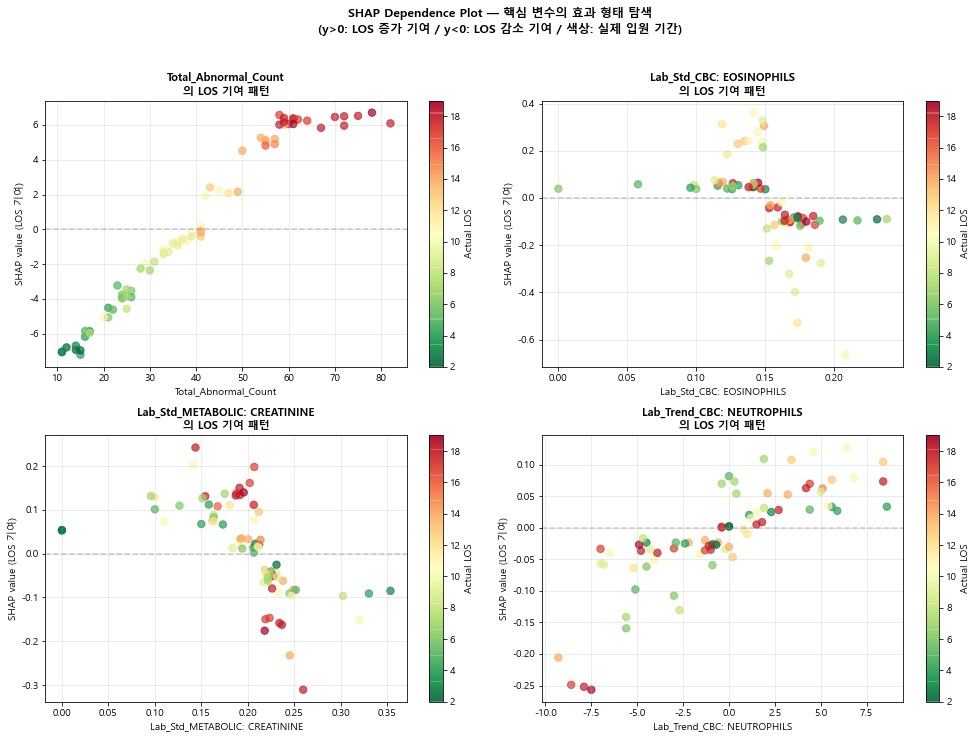


💡 해석 방법:
  선형 패턴   → 피처값이 높을수록 단순 비례로 LOS 증가
  계단 패턴   → 특정 임계값 이상에서 LOS 급증 (임상적 임계점 존재)
  무작위 패턴 → 해당 피처가 LOS에 독립적 (SHAP 기여 낮음과 일치)


In [10]:
top4 = mean_shap.head(4).index.tolist()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(top4):
    feat_idx = list(X_test.columns).index(feat)
    sc = axes[i].scatter(
        X_test[feat].values,
        shap_values[:, feat_idx],
        c=y_test.values, cmap='RdYlGn_r', alpha=0.7, s=55
    )
    axes[i].axhline(0, color='gray', linestyle='--', alpha=0.4)
    axes[i].set_xlabel(feat, fontsize=10)
    axes[i].set_ylabel('SHAP value (LOS 기여)')
    axes[i].set_title(f'{feat}\n의 LOS 기여 패턴', fontsize=11, weight='bold')
    axes[i].grid(alpha=0.3)
    plt.colorbar(sc, ax=axes[i], label='Actual LOS')

plt.suptitle('SHAP Dependence Plot — 핵심 변수의 효과 형태 탐색\n'
             '(y>0: LOS 증가 기여 / y<0: LOS 감소 기여 / 색상: 실제 입원 기간)',
             fontsize=12, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n💡 해석 방법:")
print("  선형 패턴   → 피처값이 높을수록 단순 비례로 LOS 증가")
print("  계단 패턴   → 특정 임계값 이상에서 LOS 급증 (임상적 임계점 존재)")
print("  무작위 패턴 → 해당 피처가 LOS에 독립적 (SHAP 기여 낮음과 일치)")

---
## 10. 예측 실패 패턴 분석 — 모델이 틀리는 환자는 누구인가?

Test R²=0.918이지만 틀리는 19개 케이스(대오차 상위 25%)에서 더 많은 것을 배운다.  
잔차 분포와 오차 패턴을 통해 현재 피처셋의 한계와 데이터 구조를 탐색한다.


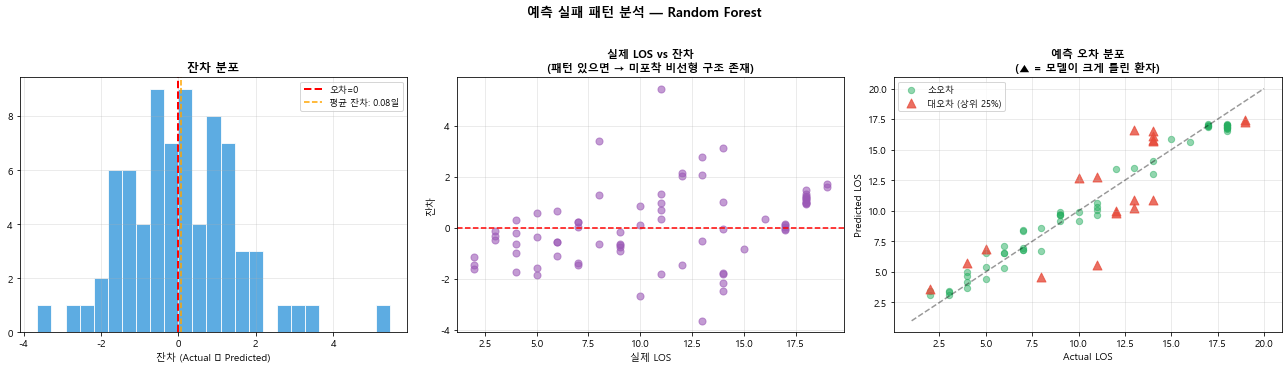

잔차 통계: 평균=0.077일, std=1.500일
대오차 케이스 수 (|잔차| > 1.6일): 19개

💡 해석:
  실제 LOS가 매우 길거나 짧은 극단 케이스에서 오차가 클수록
  → 현재 피처가 포착하지 못하는 임상 복잡성(진단 중증도 등)이 있음을 시사


In [11]:
residuals = y_test.values - yp_xgb  # XGBoost 기준 (최우수 모델)
threshold = np.percentile(np.abs(residuals), 75)
large_err = np.abs(residuals) > threshold

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 잔차 분포
axes[0].hist(residuals, bins=25, color='#3498DB', edgecolor='white', alpha=0.8)
axes[0].axvline(0, color='red', linestyle='--', lw=2, label='오차=0')
axes[0].axvline(residuals.mean(), color='orange', linestyle='--', lw=1.5,
                label=f'평균 잔차: {residuals.mean():.2f}일')
axes[0].set_xlabel('잔차 (Actual − Predicted)')
axes[0].set_title('잔차 분포', fontsize=12, weight='bold')
axes[0].legend(fontsize=9); axes[0].grid(alpha=0.3)

# Actual vs 잔차 패턴
axes[1].scatter(y_test, residuals, alpha=0.6, color='#9B59B6', s=50)
axes[1].axhline(0, color='red', linestyle='--', lw=1.5)
axes[1].set_xlabel('실제 LOS'); axes[1].set_ylabel('잔차')
axes[1].set_title('실제 LOS vs 잔차\n(패턴 있으면 → 미포착 비선형 구조 존재)',
                  fontsize=11, weight='bold'); axes[1].grid(alpha=0.3)

# 소오차 vs 대오차 케이스
axes[2].scatter(y_test[~large_err], yp_rf[~large_err],
               alpha=0.5, color='#27AE60', s=40, label='소오차')
axes[2].scatter(y_test[large_err],  yp_rf[large_err],
               alpha=0.8, color='#E74C3C', s=80, marker='^', label=f'대오차 (상위 25%)')
lim = [y_test.min()-1, y_test.max()+1]
axes[2].plot(lim, lim, 'k--', lw=1.5, alpha=0.4)
axes[2].set_xlabel('Actual LOS'); axes[2].set_ylabel('Predicted LOS')
axes[2].set_title('예측 오차 분포 (XGBoost)\n(▲ = 대오차 케이스 19개)', fontsize=11, weight='bold')
axes[2].legend(fontsize=9); axes[2].grid(alpha=0.3)

plt.suptitle('예측 실패 패턴 분석 — XGBoost (Test R²=0.918)', fontsize=13, weight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"잔차 통계: 평균={residuals.mean():.3f}일, std={residuals.std():.3f}일")
print(f"대오차 케이스 수 (|잔차| > {threshold:.1f}일): {large_err.sum()}개")
print()
print("💡 해석:")
print("  실제 LOS가 매우 길거나 짧은 극단 케이스에서 오차가 클수록")
print("  → 현재 피처가 포착하지 못하는 임상 복잡성(진단 중증도 등)이 있음을 시사")

---
## 11. 최종 결론

### 📖 분석 서사 — EDA에서 모델링까지의 완결된 흐름

```
 [EDA 관찰]                              [모델로 실증]
 ─────────────────────────────────────────────────────────────────────
 PCA PC1 설명력 7.0%, 구조 없음  →  LR R²=0.825 vs 트리 R²~0.918: 비선형 구조 확인
 LabTestCount r=0.993 (역인과)   →  제거 후에도 XGBoost R²=0.918 달성
 가설: 이상 누적이 핵심           →  Total_Abnormal_Count SHAP 압도적 1위 (기여도의 70.1%)
 가설: 단순 평균은 부족           →  Lab_Mean 그룹 기여도 최하위 (10.1%)
 가설: 변동성이 불안정성 반영      →  Std/Variability 그룹 2~3위
```

### 📊 모델 성능 요약

| 모델 | R² (Test) | MAE | RMSE | CV R² | CV std |
|------|-----------|-----|------|-------|--------|
| Linear Regression | 0.825 | 1.697일 | 2.172 | 0.712 | ±0.068 |
| Random Forest (Tuned) | 0.916 | 1.157일 | 1.502 | **0.890** | ±0.035 |
| **XGBoost** | **0.918** | **1.123일** | **1.491** | 0.872 | ±0.030 |

> **XGBoost가 Test Set 기준 최우수 성능을 기록했다.**  
> 단, CV R²는 RF(0.890)가 XGBoost(0.872)보다 높다.  
> 100명이라는 소규모 데이터 특성상, XGBoost가 특정 분할에 유리했을 가능성이 있으므로  
> **일반화 안정성 측면에서는 두 모델이 실질적으로 동등하다**고 해석하는 것이 적절하다.

### 📌 핵심 발견 4가지

1. **LabTestCount는 예측 변수가 아닌 결과 변수다**  
   r=0.993이지만 제거 후에도 R² 0.918 달성 → 진짜 임상 신호가 존재함을 확인.

2. **이상 소견의 누적이 LOS 예측의 압도적 핵심 신호다**  
   `Total_Abnormal_Count` 단일 변수의 SHAP 기여값(4.203)이  
   2위 변수(0.133)의 **31배**에 달한다. 나머지 142개 피처를 압도하는 구조.

3. **단순 평균값(Lab_Mean)은 LOS 예측에 가장 기여도가 낮다**  
   그룹 기여도 10.1%로 최하위. EDA의 초기 가설 재확인.

4. **극단적 LOS 케이스(장기/단기 입원)에서 모델 오차가 크다**  
   잔차 평균 0.077일(거의 무편향)이지만 std=1.500일.  
   대오차 19건은 진단 중증도 등 현재 피처가 포착하지 못하는 임상 요인이 관여함을 시사.

### ⚠️ 데이터 한계 및 개선 방향

| 한계 | 설명 | 개선 방향 |
|------|------|----------|
| Synthea 합성 데이터 | 실제 임상 복잡성 미반영 | MIMIC-III 등 실제 EHR 검증 |
| 소규모 (100명, 372건) | CV std ±0.03~0.07 수준, 외부 일반화 제한 | 대규모 데이터 재검증 |
| 사후 분석 | 입원 완료 데이터 기반 — 실시간 예측 불가 | 초기 N일 데이터 기반 조기 예측 모델 전환 |
| 진단 정보 미반영 | 중증도·동반 상병 누락 (Long-tail 분포로 제외) | 진단 코드 임베딩 추가 |
